# Final Project Checkpoint 4

In [13]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import numpy as np
from tqdm import tqdm
import torch
import torch.nn as nn
import torchani
import matplotlib.pyplot as plt

### Use GPU

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


### Set up AEV computer

#### AEV: Atomic Environment Vector (atomic features)

Ref: Chem. Sci., 2017, 8, 3192

In [3]:
def init_aev_computer():
    Rcr = 5.2
    Rca = 3.5
    EtaR = torch.tensor([16], dtype=torch.float, device=device)
    ShfR = torch.tensor([
        0.900000, 1.168750, 1.437500, 1.706250, 
        1.975000, 2.243750, 2.512500, 2.781250, 
        3.050000, 3.318750, 3.587500, 3.856250, 
        4.125000, 4.393750, 4.662500, 4.931250
    ], dtype=torch.float, device=device)


    EtaA = torch.tensor([8], dtype=torch.float, device=device)
    Zeta = torch.tensor([32], dtype=torch.float, device=device)
    ShfA = torch.tensor([0.90, 1.55, 2.20, 2.85], dtype=torch.float, device=device)
    ShfZ = torch.tensor([
        0.19634954, 0.58904862, 0.9817477, 1.37444680, 
        1.76714590, 2.15984490, 2.5525440, 2.94524300
    ], dtype=torch.float, device=device)

    num_species = 4
    aev_computer = torchani.AEVComputer(
        Rcr, Rca, EtaR, ShfR, EtaA, Zeta, ShfA, ShfZ, num_species
    )
    return aev_computer

aev_computer = init_aev_computer()
aev_dim = aev_computer.aev_length
print(aev_dim)

384


### Prepare dataset & split

In [4]:
def load_ani_dataset(dspath):
    self_energies = torch.tensor([
        0.500607632585, -37.8302333826,
        -54.5680045287, -75.0362229210
    ], dtype=torch.float, device=device)
    energy_shifter = torchani.utils.EnergyShifter(None)
    species_order = ['H', 'C', 'N', 'O']

    dataset = torchani.data.load(dspath)
    dataset = dataset.subtract_self_energies(energy_shifter, species_order)
    dataset = dataset.species_to_indices(species_order)
    dataset = dataset.shuffle()
    return dataset

dataset = load_ani_dataset("./ani_gdb_s01_to_s04.h5")
# Use dataset.split method to do split
train_data, val_data, test_data = dataset.split(0.8, 0.1, 0.1)

### Batching

In [5]:
batch_size = 8192
# use dataset.collate(...).cache() method to do batching
train_data_loader = train_data.collate(batch_size).cache()
val_data_loader = val_data.collate(batch_size).cache()
test_data_loader = test_data.collate(batch_size).cache()

### Torchani API

In [6]:
class AtomicNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(384, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
    
    def forward(self, x):
        return self.layers(x)

net_H = AtomicNet()
net_C = AtomicNet()
net_N = AtomicNet()
net_O = AtomicNet()

# ANI model requires a network for each atom type
# use torch.ANIModel() to compile atomic networks
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(
    aev_computer,
    ani_net
).to(device)

In [7]:
train_data_batch = next(iter(train_data_loader))

loss_func = nn.MSELoss()
species = train_data_batch['species'].to(device)
coords = train_data_batch['coordinates'].to(device)
true_energies = train_data_batch['energies'].to(device).float()
_, pred_energies = model((species, coords))
loss = loss_func(true_energies, pred_energies)
print(loss)

tensor(0.0958, device='cuda:0', grad_fn=<MseLossBackward0>)


In [8]:
class ANITrainer:
    def __init__(self, model, batch_size, learning_rate, epoch, l2):
        self.model = model
        
        num_params = sum(item.numel() for item in model.parameters())
        print(f"{model.__class__.__name__} - Number of parameters: {num_params}")
        
        self.batch_size = batch_size
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=learning_rate, weight_decay=l2)
        self.epoch = epoch
    
    def train(self, train_data, val_data, early_stop=True, draw_curve=True):
        self.model.train()
        
        # init data loader
        print("Initialize training data...")
        train_data_loader = train_data.collate(self.batch_size).cache()
        
        # definition of loss function: MSE is a good choice! 
        loss_func = nn.MSELoss()
        
        # record epoch losses
        train_loss_list = []
        val_loss_list = []
        lowest_val_loss = np.inf
        
        for i in tqdm(range(self.epoch), leave=True):
            train_epoch_loss = 0.0
            for train_data_batch in train_data_loader:
                
                # compute energies
                species = train_data_batch['species'].to(device)
                coordinates = train_data_batch['coordinates'].to(device)
                true_energies = train_data_batch['energies'].to(device).float()
                
                _, pred_energies = self.model((species, coordinates))
                
                # compute loss
                batch_loss = loss_func(pred_energies, true_energies)
                
                # do a step
                self.optimizer.zero_grad()
                batch_loss.backward()
                self.optimizer.step()
                
                batch_importance = species.shape[0]
                train_epoch_loss += batch_loss.item() * batch_importance
            
            # use the self.evaluate to get loss on the validation set 
            val_epoch_loss = self.evaluate(val_data)
            
            # append the losses
            train_loss_list.append(train_epoch_loss / len(train_data))
            val_loss_list.append(val_epoch_loss / len(val_data))
            
            if early_stop:
                if val_epoch_loss < lowest_val_loss:
                    lowest_val_loss = val_epoch_loss
                    weights = self.model.state_dict()
        
        if draw_curve:
            fig, ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)
            ax.set_yscale("log")
            # Plot train loss and validation loss
            ax.plot(epochs, train_loss_list, label='Train')
            ax.plot(epochs, val_loss_list, label='Validation')
            ax.legend()
            ax.set_xlabel("# Batch")
            ax.set_ylabel("Loss")
        
        if early_stop:
            self.model.load_state_dict(weights)
        
        return train_loss_list, val_loss_list
    
    
    def evaluate(self, data, draw_plot=False):
        
        # init data loader
        data_loader = data.collate(self.batch_size).cache()
        
        # init loss function
        loss_func = nn.MSELoss()
        total_loss = 0.0
        
        if draw_plot:
            true_energies_all = []
            pred_energies_all = []
            
        with torch.no_grad():
            for batch_data in data_loader:
                
                # compute energies
                species = batch_data['species'].to(device)
                coordinates = batch_data['coordinates'].to(device)
                true_energies = batch_data['energies'].to(device).float()
                
                _, pred_energies = self.model((species, coordinates))
                
                # compute loss
                batch_loss = loss_func(pred_energies, true_energies)

                batch_importance = species.shape[0]
                total_loss += batch_loss.item() * batch_importance
                
                if draw_plot:
                    true_energies_all.append(true_energies.detach().cpu().numpy().flatten())
                    pred_energies_all.append(pred_energies.detach().cpu().numpy().flatten())

        if draw_plot:
            true_energies_all = np.concatenate(true_energies_all)
            pred_energies_all = np.concatenate(pred_energies_all)
            # Report the mean absolute error
            # The unit of energies in the dataset is hartree
            # please convert it to kcal/mol when reporting the mean absolute error
            # 1 hartree = 627.5094738898777 kcal/mol
            # MAE = mean(|true - pred|)
            hartree2kcalmol = 627.5094738898777
            mae = np.mean(np.abs(true_energies_all - pred_energies_all)) * hartree2kcalmol
            fig, ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)
            ax.scatter(true_energies_all, pred_energies_all, label=f"MAE: {mae:.2f} kcal/mol", s=2)
            ax.set_xlabel("Ground Truth")
            ax.set_ylabel("Predicted")
            xmin, xmax = ax.get_xlim()
            ymin, ymax = ax.get_ylim()
            vmin, vmax = min(xmin, ymin), max(xmax, ymax)
            ax.set_xlim(vmin, vmax)
            ax.set_ylim(vmin, vmax)
            ax.plot([vmin, vmax], [vmin, vmax], color='red')
            ax.legend()
            
        return total_loss
        

In [16]:
class ANITrainer:
    def __init__(self, model, batch_size, learning_rate, epoch, l2):
        self.model = model
        
        num_params = sum(item.numel() for item in model.parameters())
        print(f"{model.__class__.__name__} - Number of parameters: {num_params}")
        
        self.batch_size = batch_size
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=learning_rate, weight_decay=l2)
        self.epoch = epoch
    
    def train(self, train_data, val_data, early_stop=True, draw_curve=True):
        self.model.train()
        
        # init data loader
        print("Initialize training data...")
        train_data_loader = train_data.collate(self.batch_size).cache()
        
        # definition of loss function: MSE is a good choice! 
        loss_func = nn.MSELoss()
        
        # record epoch losses
        train_loss_list = []
        val_loss_list = []
        lowest_val_loss = np.inf
        
        for i in tqdm(range(self.epoch), leave=True):
            train_epoch_loss = 0.0
            for train_data_batch in train_data_loader:
                
                # compute energies
                species = train_data_batch['species'].to(device)
                coordinates = train_data_batch['coordinates'].to(device)
                true_energies = train_data_batch['energies'].to(device).float()
                
                _, pred_energies = self.model((species, coordinates))
                
                # compute loss
                batch_loss = loss_func(pred_energies, true_energies)
                
                # do a step
                self.optimizer.zero_grad()
                batch_loss.backward()
                self.optimizer.step()
                
                batch_importance = species.shape[0]
                train_epoch_loss += batch_loss.item() * batch_importance
            
            # use the self.evaluate to get loss on the validation set 
            val_epoch_loss = self.evaluate(val_data)
            
            # append the losses
            train_loss_list.append(train_epoch_loss / len(train_data))
            val_loss_list.append(val_epoch_loss / len(val_data))
            
            if early_stop:
                if val_epoch_loss < lowest_val_loss:
                    lowest_val_loss = val_epoch_loss
                    weights = self.model.state_dict()
        
        if draw_curve:
            fig, ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)
            ax.set_yscale("log")
            epoch_range = range(1, self.epoch + 1)
            # Plot train loss and validation loss
            ax.plot(epoch_range, train_loss_list, label='Train')
            ax.plot(epoch_range, val_loss_list, label='Validation')
            ax.legend()
            ax.set_xlabel("# Batch")
            ax.set_ylabel("Loss")
        
        if early_stop:
            self.model.load_state_dict(weights)
        
        return train_loss_list, val_loss_list
    
    
    def evaluate(self, data, draw_plot=False):
        
        # init data loader
        data_loader = data.collate(self.batch_size).cache()
        
        # init loss function
        loss_func = nn.MSELoss()
        total_loss = 0.0
        
        if draw_plot:
            true_energies_all = []
            pred_energies_all = []
            
        with torch.no_grad():
            for batch_data in data_loader:
                
                # compute energies
                species = batch_data['species'].to(device)
                coordinates = batch_data['coordinates'].to(device)
                true_energies = batch_data['energies'].to(device).float()
                
                _, pred_energies = self.model((species, coordinates))
                
                # compute loss
                batch_loss = loss_func(pred_energies, true_energies)

                batch_importance = species.shape[0]
                total_loss += batch_loss.item() * batch_importance
                
                if draw_plot:
                    true_energies_all.append(true_energies.detach().cpu().numpy().flatten())
                    pred_energies_all.append(pred_energies.detach().cpu().numpy().flatten())

        if draw_plot:
            true_energies_all = np.concatenate(true_energies_all)
            pred_energies_all = np.concatenate(pred_energies_all)
            # Report the mean absolute error
            # The unit of energies in the dataset is hartree
            # please convert it to kcal/mol when reporting the mean absolute error
            # 1 hartree = 627.5094738898777 kcal/mol
            # MAE = mean(|true - pred|)
            hartree2kcalmol = 627.5094738898777
            mae = np.mean(np.abs(true_energies_all - pred_energies_all)) * hartree2kcalmol
            fig, ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)
            ax.scatter(true_energies_all, pred_energies_all, label=f"MAE: {mae:.2f} kcal/mol", s=2)
            ax.set_xlabel("Ground Truth")
            ax.set_ylabel("Predicted")
            xmin, xmax = ax.get_xlim()
            ymin, ymax = ax.get_ylim()
            vmin, vmax = min(xmin, ymin), max(xmax, ymax)
            ax.set_xlim(vmin, vmax)
            ax.set_ylim(vmin, vmax)
            ax.plot([vmin, vmax], [vmin, vmax], color='red')
            ax.legend()
            
        return total_loss
        

In [10]:
class AtomicNet(nn.Module):
    def __init__(self, dropout_rate=0.1):
        super().__init__()
        # Deeper network: 384 -> 128 -> 64 -> 1
        self.layers = nn.Sequential(
            nn.Linear(384, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(64, 1)
        )
    
    def forward(self, x):
        return self.layers(x)

net_H = AtomicNet(dropout_rate=0.1)
net_C = AtomicNet(dropout_rate=0.1)
net_N = AtomicNet(dropout_rate=0.1)
net_O = AtomicNet(dropout_rate=0.1)

ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])

model = nn.Sequential(
    aev_computer,
    ani_net
).to(device)

In [11]:
class AtomicNet(nn.Module):
    def __init__(self, dropout_rate=0.1):
        super().__init__()
        # Deeper network: 384 -> 128 -> 64 -> 1
        self.layers = nn.Sequential(
            nn.Linear(384, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate), # Randomly drops neurons to prevent overfitting
            nn.Linear(128, 64),       # Added extra capacity
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(64, 1)
        )
    
    def forward(self, x):
        return self.layers(x)

# Re-initialize the atomic networks with the new architecture
net_H = AtomicNet(dropout_rate=0.1)
net_C = AtomicNet(dropout_rate=0.1)
net_N = AtomicNet(dropout_rate=0.1)
net_O = AtomicNet(dropout_rate=0.1)

# Re-compile the ANI model
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])

# Re-combine with the AEV computer
model = nn.Sequential(
    aev_computer,
    ani_net
).to(device)

Sequential - Number of parameters: 230404
Initialize training data...


100%|██████████| 50/50 [07:18<00:00,  8.77s/it]


Total Test Loss (Sum of MSE): 1.1366


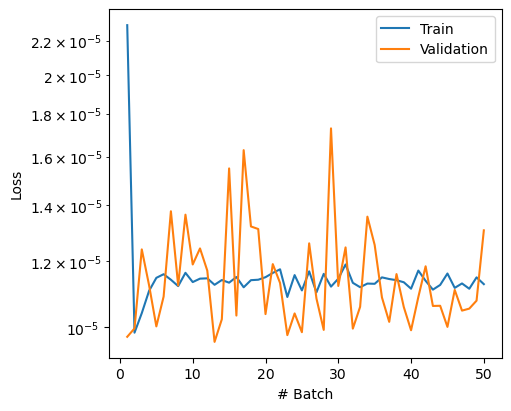

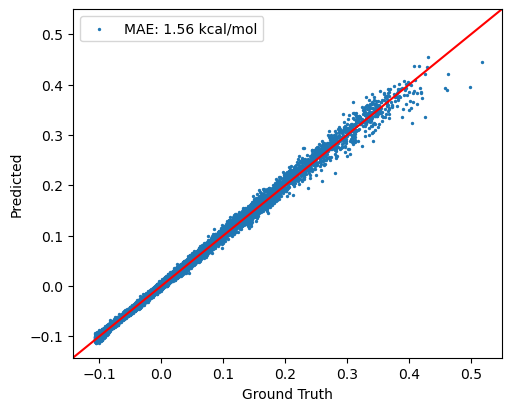

In [17]:
batch_size = 2048
learning_rate = 5e-4
epochs = 50
l2_weight_decay = 1e-6 

trainer = ANITrainer(
    model=model, 
    batch_size=batch_size, 
    learning_rate=learning_rate, 
    epoch=epochs, 
    l2=l2_weight_decay
)

train_losses, val_losses = trainer.train(
    train_data=train_data, 
    val_data=val_data, 
    early_stop=True, 
    draw_curve=True
)

test_loss = trainer.evaluate(
    data=test_data, 
    draw_plot=True
)
print(f"Total Test Loss (Sum of MSE): {test_loss:.4f}")

In [ ]:
import math
def get_fresh_model():
    net_H = AtomicNet(dropout_rate=0.1)
    net_C = AtomicNet(dropout_rate=0.1)
    net_N = AtomicNet(dropout_rate=0.1)
    net_O = AtomicNet(dropout_rate=0.1)

    ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])

    model = nn.Sequential(
        aev_computer,
        ani_net
    ).to(device)
    
    return model

num_folds = 5
batch_size = 2048
learning_rate = 5e-4
epochs = 30
l2_weight_decay = 1e-6 

ensemble_models = []

for fold in range(num_folds):
    print(f"\n--- Starting Run {fold + 1}/{num_folds} ---")
    
    shuffled_dataset = dataset.shuffle()
    train_data, val_data = shuffled_dataset.split(0.9, 0.1) 
    
    current_model = get_fresh_model()
    trainer = ANITrainer(
        model=current_model, 
        batch_size=batch_size, 
        learning_rate=learning_rate, 
        epoch=epochs, 
        l2=l2_weight_decay
    )
    
    train_losses, val_losses = trainer.train(
        train_data=train_data, 
        val_data=val_data, 
        early_stop=True, 
        draw_curve=False
    )
    
    ensemble_models.append(current_model)
    print(f"Run {fold + 1} completed. Best Val Loss: {min(val_losses):.4f}")

test_loader = dataset.collate(batch_size).cache()

total_mae = 0.0
total_items = 0
hartree2kcalmol = 627.5094738898777

with torch.no_grad():
    for batch in test_loader:
        species = batch['species'].to(device)
        coords = batch['coordinates'].to(device)
        true_energies = batch['energies'].to(device).float()
        
        ensemble_preds = []
        for model in ensemble_models:
            model.eval()
            _, pred_energies = model((species, coords))
            ensemble_preds.append(pred_energies)
            
        avg_pred_energies = torch.stack(ensemble_preds).mean(dim=0)
        
        mae = torch.abs(true_energies - avg_pred_energies).sum().item()
        total_mae += mae
        total_items += species.shape[0]

final_ensemble_mae = (total_mae / total_items) * hartree2kcalmol
print(f"Final Ensemble Mean Absolute Error: {final_ensemble_mae:.4f} kcal/mol")

best_val_mse_hartrees = min(val_losses)
rmse_hartrees = math.sqrt(best_val_mse_hartrees)
rmse_kcal_mol = rmse_hartrees * 627.5094738898777
print(f"Validation RMSE: {rmse_kcal_mol:.4f} kcal/mol")

Results from running the above code:

--- Starting Run 1/5 ---
100%|██████████| 30/30 [03:58<00:00,  7.94s/it]
Run 1 completed. Best Val Loss: 0.0000

--- Starting Run 2/5 ---
100%|██████████| 30/30 [04:55<00:00,  9.83s/it]
Run 2 completed. Best Val Loss: 0.0000

--- Starting Run 3/5 ---
100%|██████████| 30/30 [04:03<00:00,  8.11s/it]
Run 3 completed. Best Val Loss: 0.0000

--- Starting Run 4/5 ---
100%|██████████| 30/30 [03:34<00:00,  7.16s/it]
Run 4 completed. Best Val Loss: 0.0000

--- Starting Run 5/5 ---
100%|██████████| 30/30 [03:32<00:00,  7.09s/it]
Run 5 completed. Best Val Loss: 0.0000

Final Ensemble Mean Absolute Error: 1.3883 kcal/mol

Validation RMSE: 2.6163 kcal/mol